# KPI and Trend Analysis

## Business Question

> Sales performance appears to be declining in recent months. When did the decline begin, and was it driven by order volume, average order value, or both?

## Primary Metrics

- **Booked GMV:** Total customer payment value
- **Order Count:** Number of valid orders
- **AOV:** Booked GMV divided by order count
- **Items per Order:** Average number of order items
- **GMV per Active Day:** Monthly GMV normalized by observed sales days

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

order_sales = spark.table(
    "workspace.olist.order_sales"
)

In [0]:
monthly_kpis_base = (
    order_sales
    .groupBy(
        "purchase_month"
    )
    .agg(
        F.sum(
            "booked_gmv"
        ).alias("booked_gmv"),

        F.count(
            "*"
        ).alias("order_count"),

        F.sum(
            "item_count"
        ).alias("item_count"),

        F.countDistinct(
            "purchase_date"
        ).alias("active_days"),

        F.min(
            "purchase_date"
        ).alias("first_purchase_date"),

        F.max(
            "purchase_date"
        ).alias("last_purchase_date")
    )
    .withColumn(
        "aov",
        F.col("booked_gmv") /
        F.col("order_count")
    )
    .withColumn(
        "items_per_order",
        F.col("item_count") /
        F.col("order_count")
    )
    .withColumn(
        "calendar_days",
        F.dayofmonth(
            F.last_day("purchase_month")
        )
    )
    .withColumn(
        "coverage_pct",
        (
            F.col("active_days") /
            F.col("calendar_days")
        ) * 100
    )
    .withColumn(
        "gmv_per_active_day",
        F.col("booked_gmv") /
        F.col("active_days")
    )
)

In [0]:
month_window = Window.orderBy(
    "purchase_month"
)

monthly_kpis = (
    monthly_kpis_base
    .withColumn(
        "previous_month_gmv",
        F.lag(
            "booked_gmv"
        ).over(month_window)
    )
    .withColumn(
        "previous_month_order_count",
        F.lag(
            "order_count"
        ).over(month_window)
    )
    .withColumn(
        "previous_month_aov",
        F.lag(
            "aov"
        ).over(month_window)
    )
    .withColumn(
        "gmv_mom_pct",
        (
            (
                F.col("booked_gmv") /
                F.col("previous_month_gmv")
            ) - 1
        ) * 100
    )
    .withColumn(
        "order_count_mom_pct",
        (
            (
                F.col("order_count") /
                F.col("previous_month_order_count")
            ) - 1
        ) * 100
    )
    .withColumn(
        "aov_mom_pct",
        (
            (
                F.col("aov") /
                F.col("previous_month_aov")
            ) - 1
        ) * 100
    )
    .orderBy(
        "purchase_month"
    )
)

In [0]:
display(
    monthly_kpis.select(
        "purchase_month",
        F.round(
            "booked_gmv",
            2
        ).alias("booked_gmv"),
        "order_count",
        F.round(
            "aov",
            2
        ).alias("aov"),
        F.round(
            "items_per_order",
            3
        ).alias("items_per_order"),
        "active_days",
        "calendar_days",
        F.round(
            "coverage_pct",
            2
        ).alias("coverage_pct"),
        F.round(
            "gmv_per_active_day",
            2
        ).alias("gmv_per_active_day"),
        F.round(
            "gmv_mom_pct",
            2
        ).alias("gmv_mom_pct"),
        F.round(
            "order_count_mom_pct",
            2
        ).alias("order_count_mom_pct"),
        F.round(
            "aov_mom_pct",
            2
        ).alias("aov_mom_pct")
    )
)

purchase_month,booked_gmv,order_count,aov,items_per_order,active_days,calendar_days,coverage_pct,gmv_per_active_day,gmv_mom_pct,order_count_mom_pct,aov_mom_pct
2017-01-01,137006.76,787,174.09,1.211,27,31,87.1,5074.32,null,null,null
2017-02-01,283621.94,1718,165.09,1.127,28,28,100.0,10129.36,107.01,118.3,-5.17
2017-03-01,425656.40,2617,162.65,1.137,31,31,100.0,13730.85,50.08,52.33,-1.48
2017-04-01,405988.38,2377,170.80,1.119,30,30,100.0,13532.95,-4.62,-9.17,5.01
2017-05-01,582926.16,3640,160.14,1.128,31,31,100.0,18804.07,43.58,53.13,-6.24
2017-06-01,499827.47,3205,155.95,1.114,30,30,100.0,16660.92,-14.26,-11.95,-2.62
2017-07-01,578858.58,3946,146.70,1.139,31,31,100.0,18672.86,15.81,23.12,-5.94
2017-08-01,662071.77,4272,154.98,1.143,31,31,100.0,21357.15,14.38,8.26,5.65
2017-09-01,717195.22,4227,169.67,1.139,30,30,100.0,23906.51,8.33,-1.05,9.48
2017-10-01,764785.28,4547,168.20,1.166,31,31,100.0,24670.49,6.64,7.57,-0.87


In [0]:
year_window = Window.orderBy(
    "purchase_month"
)

monthly_kpis_extended = (
    monthly_kpis
    .withColumn(
        "previous_year_gmv",
        F.lag(
            "booked_gmv",
            12
        ).over(year_window)
    )
    .withColumn(
        "gmv_yoy_pct",
        (
            (
                F.col("booked_gmv") /
                F.col("previous_year_gmv")
            ) - 1
        ) * 100
    )
)

In [0]:
display(
    monthly_kpis_extended
    .filter(F.col("purchase_month") >= "2018-01-01")
    .select(
        "purchase_month",
        F.round("booked_gmv", 2).alias("booked_gmv"),
        "order_count",
        F.round("aov", 2).alias("aov"),
        F.round("gmv_mom_pct", 2).alias("gmv_mom_pct"),
        F.round("order_count_mom_pct", 2).alias("order_count_mom_pct"),
        F.round("aov_mom_pct", 2).alias("aov_mom_pct"),
        F.round("gmv_yoy_pct", 2).alias("gmv_yoy_pct"),
        F.round("coverage_pct", 2).alias("coverage_pct")
    )
    .orderBy("purchase_month")
)

purchase_month,booked_gmv,order_count,aov,gmv_mom_pct,order_count_mom_pct,aov_mom_pct,gmv_yoy_pct,coverage_pct
2018-01-01,1102639.41,7187,153.42,27.97,27.93,0.03,704.81,100.0
2018-02-01,979828.63,6624,147.92,-11.14,-7.83,-3.59,245.47,100.0
2018-03-01,1152736.74,7168,160.82,17.65,8.21,8.72,170.81,100.0
2018-04-01,1156303.91,6919,167.12,0.31,-3.47,3.92,184.81,100.0
2018-05-01,1145748.63,6833,167.68,-0.91,-1.24,0.33,96.55,100.0
2018-06-01,1020494.29,6145,166.07,-10.93,-10.07,-0.96,104.17,100.0
2018-07-01,1039880.16,6233,166.83,1.90,1.43,0.46,79.64,100.0
2018-08-01,996896.15,6421,155.26,-4.13,3.02,-6.94,50.57,93.55


In [0]:
recent_daily_kpis = (
    monthly_kpis_extended
    .withColumn(
        "orders_per_active_day",
        F.col("order_count") / F.col("active_days")
    )
    .withColumn(
        "previous_daily_gmv",
        F.lag("gmv_per_active_day").over(month_window)
    )
    .withColumn(
        "daily_gmv_mom_pct",
        (
            F.col("gmv_per_active_day") /
            F.col("previous_daily_gmv") - 1
        ) * 100
    )
)

display(
    recent_daily_kpis
    .filter(F.col("purchase_month") >= "2018-05-01")
    .select(
        "purchase_month",
        "active_days",
        F.round("coverage_pct", 2).alias("coverage_pct"),
        F.round("booked_gmv", 2).alias("booked_gmv"),
        F.round("gmv_per_active_day", 2).alias("gmv_per_active_day"),
        F.round("daily_gmv_mom_pct", 2).alias("daily_gmv_mom_pct"),
        F.round("orders_per_active_day", 2).alias("orders_per_active_day"),
        F.round("aov", 2).alias("aov")
    )
    .orderBy("purchase_month")
)

purchase_month,active_days,coverage_pct,booked_gmv,gmv_per_active_day,daily_gmv_mom_pct,orders_per_active_day,aov
2018-05-01,31,100.0,1145748.63,36959.63,-4.11,220.42,167.68
2018-06-01,30,100.0,1020494.29,34016.48,-7.96,204.83,166.07
2018-07-01,31,100.0,1039880.16,33544.52,-1.39,201.06,166.83
2018-08-01,29,93.55,996896.15,34375.73,2.48,221.41,155.26


## Preliminary KPI Diagnosis

- The comparable full-month decline begins in June 2018.
- From May to July, booked GMV declined by approximately 9.24%.
- Order count declined by approximately 8.78%, while AOV declined by only 0.51%.
- Therefore, the May-to-July GMV decline was primarily volume-driven.
- August contains only 29 active days and should not be compared using monthly totals alone.
- August daily GMV increased by 2.48% compared with July.
- Order velocity recovered, but AOV declined from 166.83 BRL to 155.26 BRL.
- The recent performance pattern therefore consists of an initial order-volume contraction followed by an AOV deterioration.

In [0]:
rolling_window = (
    Window
    .orderBy("purchase_month")
    .rowsBetween(-2, 0)
)

monthly_kpi_trend = (
    recent_daily_kpis
    .withColumn(
        "gmv_3m_avg",
        F.avg("booked_gmv").over(rolling_window)
    )
    .withColumn(
        "order_count_3m_avg",
        F.avg("order_count").over(rolling_window)
    )
    .withColumn(
        "aov_3m_avg",
        F.avg("aov").over(rolling_window)
    )
)

display(
    monthly_kpi_trend
    .filter(F.col("purchase_month") >= "2018-01-01")
    .select(
        "purchase_month",
        F.round("booked_gmv", 2).alias("booked_gmv"),
        F.round("gmv_3m_avg", 2).alias("gmv_3m_avg"),
        "order_count",
        F.round("order_count_3m_avg", 2).alias("order_count_3m_avg"),
        F.round("aov", 2).alias("aov"),
        F.round("aov_3m_avg", 2).alias("aov_3m_avg")
    )
    .orderBy("purchase_month")
)

purchase_month,booked_gmv,gmv_3m_avg,order_count,order_count_3m_avg,aov,aov_3m_avg
2018-01-01,1102639.41,1045547.53,7187,6742.0,153.42,154.92
2018-02-01,979828.63,981371.90,6624,6476.33,147.92,151.57
2018-03-01,1152736.74,1078401.59,7168,6993.0,160.82,154.05
2018-04-01,1156303.91,1096289.76,6919,6903.67,167.12,158.62
2018-05-01,1145748.63,1151596.43,6833,6973.33,167.68,165.21
2018-06-01,1020494.29,1107515.61,6145,6632.33,166.07,166.96
2018-07-01,1039880.16,1068707.69,6233,6403.67,166.83,166.86
2018-08-01,996896.15,1019090.20,6421,6266.33,155.26,162.72


In [0]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"WARN WindowExpression: No Partition Defined.*",
    category=UserWarning
)

## Trend visualizations

Monthly GMV is compared with its three-month moving average to distinguish short-term volatility from the underlying sales trend. August 2018 is marked as a partial month because it contains only 29 active days.

/Workspace/Users/erenkilicli99@gmail.com/2. Aşama/olist-sales-performance-investigation/reports/figures


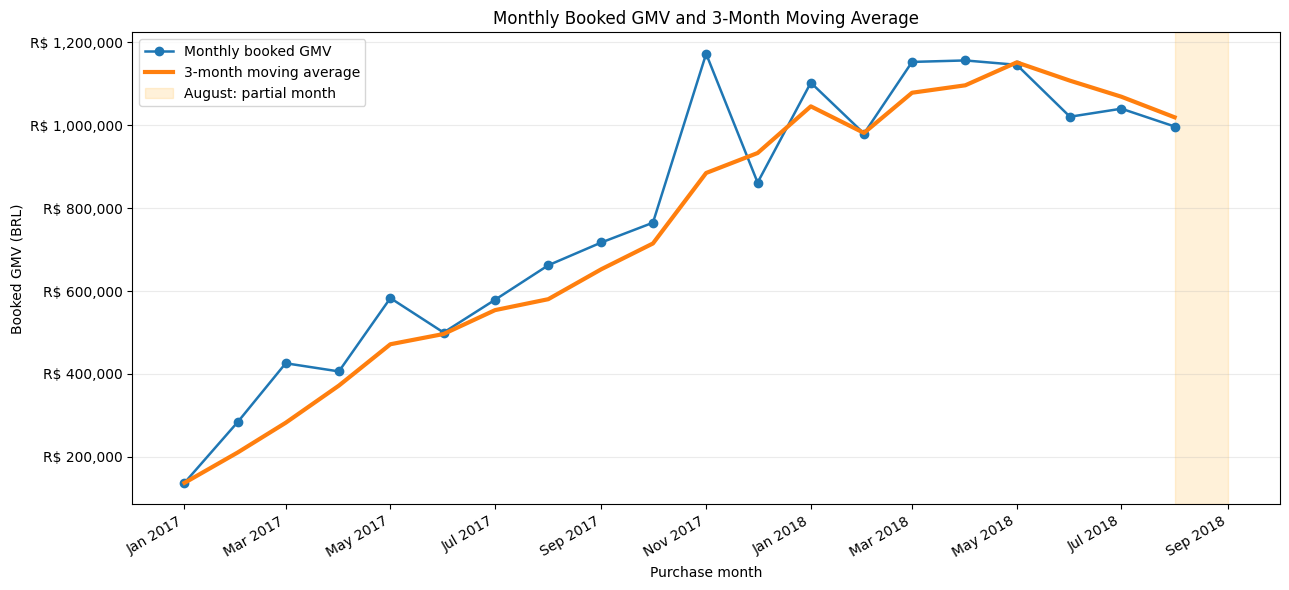

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from pathlib import Path

current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

figure_dir = repo_root / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

print(figure_dir)

trend_pd = (
    monthly_kpi_trend
    .orderBy("purchase_month")
    .select("purchase_month", "booked_gmv", "gmv_3m_avg")
    .toPandas()
)

trend_pd["purchase_month"] = pd.to_datetime(trend_pd["purchase_month"])
trend_pd["booked_gmv"] = trend_pd["booked_gmv"].astype(float)
trend_pd["gmv_3m_avg"] = trend_pd["gmv_3m_avg"].astype(float)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    trend_pd["purchase_month"], trend_pd["booked_gmv"],
    marker="o", linewidth=1.8, label="Monthly booked GMV"
)

ax.plot(
    trend_pd["purchase_month"], trend_pd["gmv_3m_avg"],
    linewidth=3, label="3-month moving average"
)

ax.axvspan(
    pd.Timestamp("2018-08-01"), pd.Timestamp("2018-09-01"),
    color="orange", alpha=0.15, label="August: partial month"
)

ax.set_title("Monthly Booked GMV and 3-Month Moving Average")
ax.set_xlabel("Purchase month")
ax.set_ylabel("Booked GMV (BRL)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(
    figure_dir / "monthly_gmv_trend.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Order volume and average order value

The following charts separate the two components of booked GMV: order volume and average order value. Separate panels are used because the metrics have different units and scales.

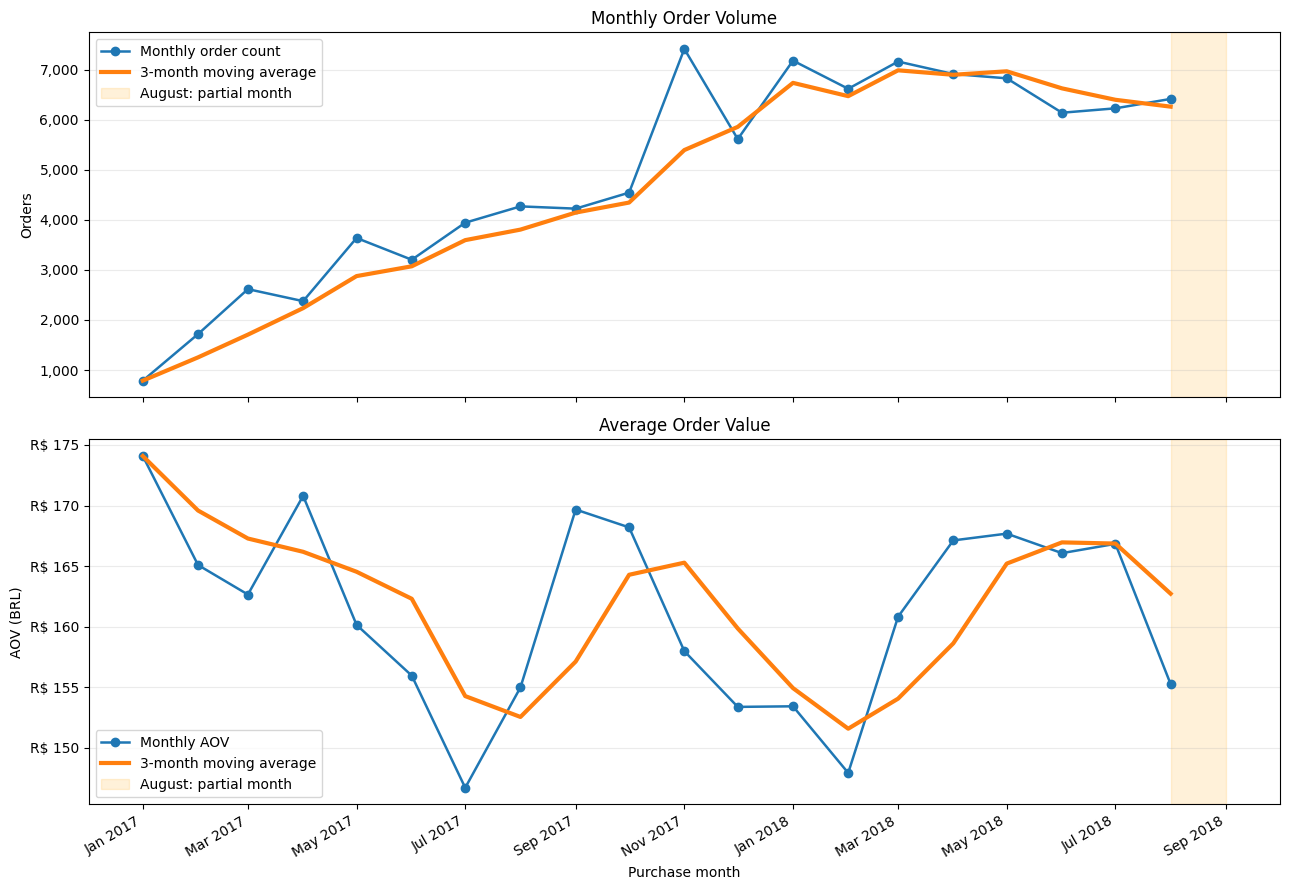

In [0]:
drivers_pd = (
    monthly_kpi_trend
    .orderBy("purchase_month")
    .select(
        "purchase_month",
        "order_count", "order_count_3m_avg",
        "aov", "aov_3m_avg"
    )
    .toPandas()
)

drivers_pd["purchase_month"] = pd.to_datetime(drivers_pd["purchase_month"])

numeric_columns = [
    "order_count", "order_count_3m_avg",
    "aov", "aov_3m_avg"
]

drivers_pd[numeric_columns] = drivers_pd[numeric_columns].astype(float)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].plot(
    drivers_pd["purchase_month"], drivers_pd["order_count"],
    marker="o", linewidth=1.8, label="Monthly order count"
)
axes[0].plot(
    drivers_pd["purchase_month"], drivers_pd["order_count_3m_avg"],
    linewidth=3, label="3-month moving average"
)
axes[0].set_title("Monthly Order Volume")
axes[0].set_ylabel("Orders")
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

axes[1].plot(
    drivers_pd["purchase_month"], drivers_pd["aov"],
    marker="o", linewidth=1.8, label="Monthly AOV"
)
axes[1].plot(
    drivers_pd["purchase_month"], drivers_pd["aov_3m_avg"],
    linewidth=3, label="3-month moving average"
)
axes[1].set_title("Average Order Value")
axes[1].set_xlabel("Purchase month")
axes[1].set_ylabel("AOV (BRL)")
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))

for ax in axes:
    ax.axvspan(
        pd.Timestamp("2018-08-01"), pd.Timestamp("2018-09-01"),
        color="orange", alpha=0.15, label="August: partial month"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fig.savefig(
    figure_dir / "order_volume_and_aov.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Recent daily performance

Daily-normalized metrics are used for the most recent months so that August 2018 can be compared fairly despite having only 29 active days.

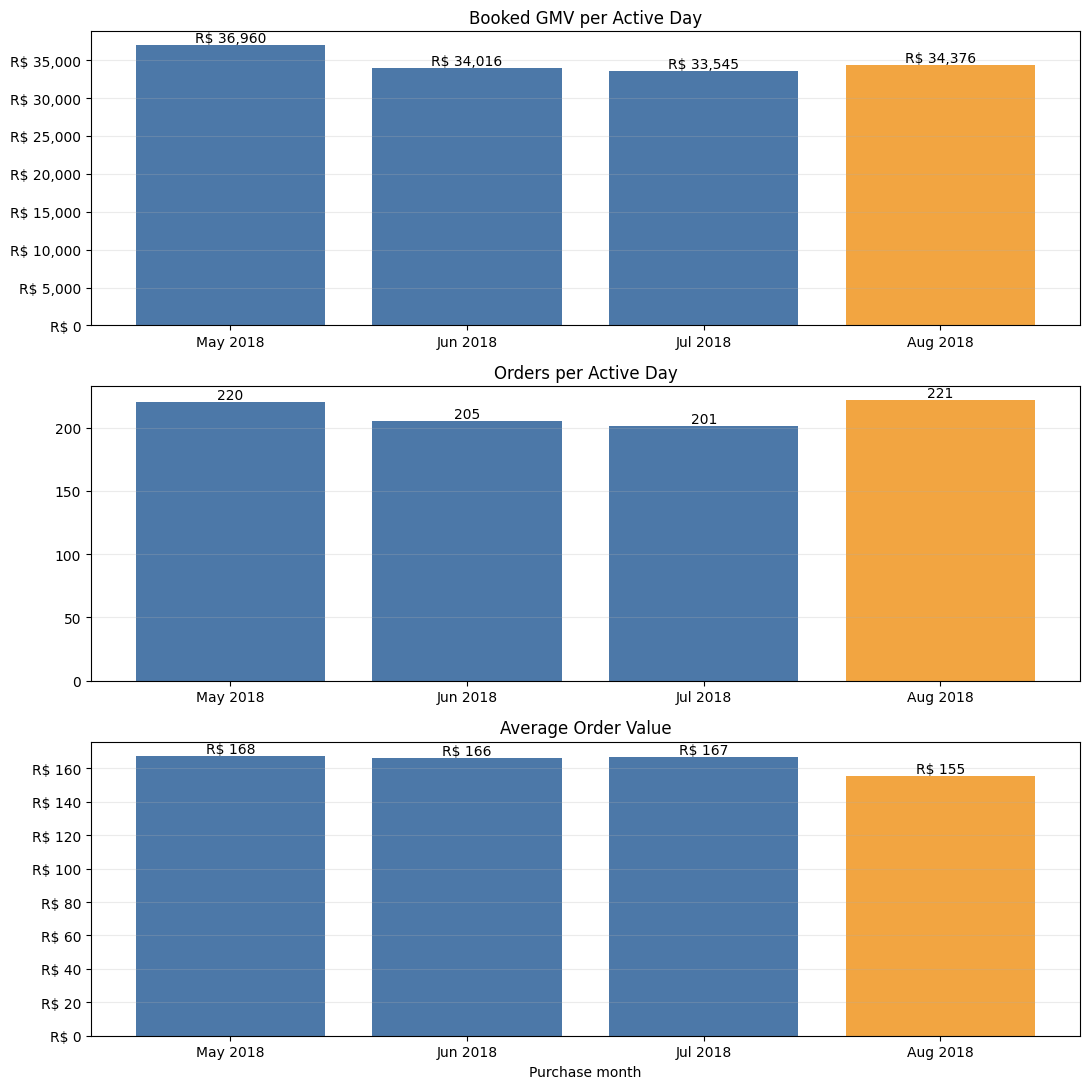

In [0]:
recent_pd = (
    monthly_kpi_trend
    .filter(F.col("purchase_month") >= "2018-05-01")
    .orderBy("purchase_month")
    .select(
        "purchase_month",
        "gmv_per_active_day",
        "orders_per_active_day",
        "aov"
    )
    .toPandas()
)

recent_pd["purchase_month"] = pd.to_datetime(recent_pd["purchase_month"])
recent_pd["month"] = recent_pd["purchase_month"].dt.strftime("%b %Y")

metrics = [
    ("gmv_per_active_day", "Booked GMV per Active Day", "R$ {:,.0f}"),
    ("orders_per_active_day", "Orders per Active Day", "{:,.0f}"),
    ("aov", "Average Order Value", "R$ {:,.0f}")
]

fig, axes = plt.subplots(3, 1, figsize=(11, 11))

for ax, (column, title, label_format) in zip(axes, metrics):
    values = recent_pd[column].astype(float)
    colors = ["#4C78A8"] * (len(recent_pd) - 1) + ["#F2A541"]

    bars = ax.bar(recent_pd["month"], values, color=colors)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            label_format.format(value),
            ha="center", va="bottom"
        )

axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
axes[2].set_xlabel("Purchase month")

plt.tight_layout()
plt.show()

fig.savefig(
    figure_dir / "recent_daily_kpis.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## KPI trend findings

- Booked GMV did not decline continuously; it reached a recent peak in May 2018.
- Between May and July, two comparable full months, booked GMV declined by 9.24%.
- During the same period, order count declined by 8.78%, while AOV declined by only 0.51%.
- Therefore, the May-to-July GMV decline was primarily driven by lower order volume.
- August contains only 29 active days, so its monthly total is not directly comparable with complete months.
- On a daily basis, August showed a volume recovery: orders per active day increased from 201 to 221.
- However, AOV declined from R$166.83 to R$155.26, limiting the GMV recovery.

**Preliminary diagnosis:** The recent sales weakness changed over time. June and July were affected mainly by lower order volume, while August showed recovering order activity but weaker basket value.

In [0]:
(
    monthly_kpi_trend.write
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.olist.monthly_kpis")
)